In [17]:
# Imports
import os
import sys
import warnings
import numpy as np
import pandas as pd
import pyfixest as pf
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadstat
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm
from typing import List
from sklearn.metrics import mean_squared_error, r2_score, log_loss
from stargazer.stargazer import Stargazer
from IPython.display import display, Latex
from statsmodels.iolib.summary2 import summary_col
pd.options.mode.chained_assignment = None
warnings.filterwarnings("ignore") 

In [2]:
share = pd.read_csv("https://osf.io/download/kbjzp/")
share = share.query("wave==4 & age>=50 & age<=64")

# Some reminder code to help explore data. 
share["br015"].unique()
share["mar_stat"].value_counts()
share.describe()

,wave,country,country_mod,int_year,int_month,female,age,eduyears_mod,sphus,br015,smoking,ever_smoked,income_pct_w4,bmi,mar_stat
count,26254.0,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000
mean,4.0,22.593205,349.048640,2011.005028,5.797364,0.562048,57.572903,10.149901,2.972538,2.252114,3.835796,2.528948,6.021025,25.195472,1.731165
std,0.0,8.230092,241.682133,0.236737,2.712384,0.496145,3.903833,6.681391,1.525931,1.879895,2.241819,3.172209,2.943781,9.284344,2.722536
min,4.0,11.000000,40.000000,2010.000000,1.000000,0.000000,50.000000,-15.000000,-15.000000,-15.000000,-15.000000,-15.000000,1.000000,-15.000000,-15.000000
25%,4.0,16.000000,203.000000,2011.000000,4.000000,0.000000,54.299999,8.000000,2.000000,1.000000,1.000000,1.000000,4.000000,23.243801,1.000000
50%,4.0,20.000000,250.000000,2011.000000,5.000000,1.000000,57.799999,11.000000,3.000000,2.000000,5.000000,1.000000,6.000000,26.026175,1.000000
75%,4.0,32.000000,616.000000,2011.000000,8.000000,1.000000,60.900002,14.000000,4.000000,4.000000,5.000000,5.000000,9.000000,29.372396,3.000000
max,4.0,35.000000,756.000000,2012.000000,12.000000,1.000000,64.000000,25.000000,5.000000,4.000000,5.000000,5.000000,10.000000,88.376396,6.000000


## Part 1
#### 1.1

In [3]:
# Filter Data
share = share.query('bmi > 0 & mar_stat > 0 & ever_smoked > 0 & smoking > 0 & br015 > 0 & sphus > 0 & eduyears_mod > 0')
share.describe()

,wave,country,country_mod,int_year,int_month,female,age,eduyears_mod,sphus,br015,smoking,ever_smoked,income_pct_w4,bmi,mar_stat
count,23926.0,23926.000000,23926.000000,23926.000000,23926.000000,23926.000000,23926.000000,23926.000000,23926.000000,23926.00000,23926.000000,23926.000000,23926.000000,23926.000000,23926.000000
mean,4.0,22.861364,342.346945,2011.001546,5.824459,0.558597,57.523869,11.432208,3.030594,2.34590,3.932208,2.872607,6.054585,26.948607,2.002508
std,0.0,8.237887,237.699239,0.236567,2.713939,0.496565,3.902150,4.072558,1.071325,1.31931,1.769497,1.995980,2.937472,4.865537,1.713964
min,4.0,11.000000,40.000000,2010.000000,1.000000,0.000000,50.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,13.493000,1.000000
25%,4.0,16.000000,203.000000,2011.000000,4.000000,0.000000,54.299999,9.000000,2.000000,1.00000,1.000000,1.000000,4.000000,23.665245,1.000000
50%,4.0,23.000000,250.000000,2011.000000,6.000000,1.000000,57.700001,12.000000,3.000000,2.00000,5.000000,1.000000,6.000000,26.277285,1.000000
75%,4.0,32.000000,528.000000,2011.000000,8.000000,1.000000,60.900002,14.000000,4.000000,4.00000,5.000000,5.000000,9.000000,29.411764,3.000000
max,4.0,35.000000,756.000000,2012.000000,12.000000,1.000000,64.000000,25.000000,5.000000,4.00000,5.000000,5.000000,10.000000,88.376396,6.000000


#### 1.2

In [4]:
share['exercise'] = ((share["br015"] == 1) | (share["br015"] == 2)).astype(int)
percentExercise = np.sum(share['exercise'])/len(share['exercise'])
percentExercise

np.float64(0.5703836830226532)

Physical activity even once a week is regular enough to potentially offer health benefits over a more sedentary lifestyle, so both a 1 or 2 in the br015 variable were coded as engaging in exercise. Under this interpretation, 57.04% of the sample would be defined as engaging in exercise. 
#### 1.3

In [5]:
share['married'] = ((share["mar_stat"] == 1) | (share["mar_stat"] == 2)).astype(int)

## Part 2

#### 2.1

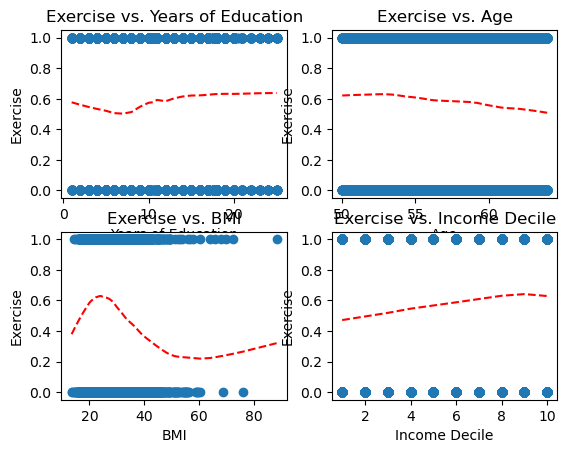

In [6]:
# Lowess Curves to Find Patterns/Splines
plt.subplot(2,2,1)
plt.scatter(share['eduyears_mod'],share['exercise'])
lowessfit1 = lowess(share['exercise'],share['eduyears_mod'],frac=1/3.0)
plt.plot(lowessfit1[:,0],lowessfit1[:,1],'r--')
plt.xlabel("Years of Education")
plt.ylabel("Exercise")
plt.title("Exercise vs. Years of Education")

plt.subplot(2,2,2)
plt.scatter(share['age'],share['exercise'])
lowessfit2 = lowess(share['exercise'],share['age'],frac=1/3.0)
plt.plot(lowessfit2[:,0],lowessfit2[:,1],'r--')
plt.xlabel("Age")
plt.ylabel("Exercise")
plt.title("Exercise vs. Age")

plt.subplot(2,2,3)
plt.scatter(share['bmi'],share['exercise'])
lowessfit3 = lowess(share['exercise'],share['bmi'],frac=1/3.0)
plt.plot(lowessfit3[:,0],lowessfit3[:,1],'r--')
plt.xlabel("BMI")
plt.ylabel("Exercise")
plt.title("Exercise vs. BMI")


plt.subplot(2,2,4)
plt.scatter(share['income_pct_w4'],share['exercise'])
lowessfit4 = lowess(share['exercise'],share['income_pct_w4'],frac=1/3.0)
plt.plot(lowessfit4[:,0],lowessfit4[:,1],'r--')
plt.xlabel("Income Decile")
plt.ylabel("Exercise")
plt.title("Exercise vs. Income Decile")

plt.show()


#### 2.2
Based on the graphs from 2.1, the splines would be most appropriate for the Years of Education, BMI, and income decile variables. The age lowess curve shows a pretty consistent decreasing trend throughout, so a spline won't be used (which likely can be explained by already using a relatively narrow age range for this sample). For income decile, the spline should be set at 9, which is when the lowess curve changes direction. For the BMI, the knots for the splines will be at 24 and 56. Finally, for the years of education, the knots for the splines will be at 7 and 17. The locations of these knots was based on where the general trend of the Lowess curve appeared to change most substantially, delineating patterns in the data. 

#### 2.3

In [7]:
# Regression i
x1 = share.loc[:,['female','age']]
x1 = sm.add_constant(x1)
y1 = share['exercise']
model1 = sm.OLS(y1,x1)
res1 = model1.fit(cov_type="HC1")

In [8]:
# Regression ii
x = share["eduyears_mod"].to_numpy()
share["edu1"] = np.minimum(x, 7)
share["edu2"] = np.minimum(np.maximum(x - 7, 0.0), 17 - 7)  
share["edu3"] = np.maximum(x - 17, 0.0)

x = share["bmi"].to_numpy()
share["bmi1"] = np.minimum(x, 24)
share["bmi2"] = np.minimum(np.maximum(x - 24, 0.0), 56 - 24)  
share["bmi3"] = np.maximum(x - 56, 0.0)

x = share["income_pct_w4"].to_numpy()
share["inc1"] = np.minimum(x, 9)
share["inc2"] = np.maximum(x - 9, 0.0)


x2 = share.loc[:,['female','age','bmi1','bmi2','bmi3','married','inc1','inc2','edu1','edu2','edu3']]
x2 = sm.add_constant(x2)
y2 = share['exercise']
model2 = sm.OLS(y2,x2)
res2 = model2.fit(cov_type="HC1")

In [9]:
# Regression iii
cntryDummies = pd.get_dummies(share['country'],prefix='Country ',prefix_sep=' ').astype(int)
x3 = pd.concat([share.loc[:,['female','age','bmi1','bmi2','bmi3','married','inc1','inc2','edu1','edu2','edu3']],cntryDummies],axis=1)
x3 = sm.add_constant(x3)
y3 = share['exercise']
model3 = sm.OLS(y3,x3)
res3 = model3.fit(cov_type="HC1")

In [10]:
varNames = {'female':'Female', 'age':'Age', 'bmi1':'BMI <= 24', 'bmi2':'24 < BMI <= 56', 'bmi3':'BMI > 56', 'married':'Married', 'inc1':'Income Decile <= 9',
            'inc2':'Income Decile > 9', 'edu1': "Years of Education <= 7", 'edu2': '7 < Years of Education <= 17', 'edu3': 'Years of Education > 17', 'const' : 'Constant'}

stargazer = Stargazer([res1, res2, res3])
stargazer.covariate_order(['female','age','married', 'bmi1','bmi2', 'bmi3', 'edu1','edu2','edu3', 'inc1','inc2'] + cntryDummies.columns.tolist() + ['const'])
stargazer.rename_covariates(varNames)
stargazer.custom_columns(['Model 1','Model 2','Model 3'])
stargazer.dependent_variable_name('Exercise')
stargazer
#display(Latex(stargazer.render_latex()))



#### 2.4
In both models 2 and 3, the coefficient on female is -0.093, significant at 99%, which means that, holding all other variables constant, women are, on average, 9.3% less likely to exercise than men. The age variable has a coefficient of -0.007 (or -0.008 in model 3), which means that, on average, holding all other factors constant, for every year older a person is, they are 0.7% (or 0.8%) less likely to exercise. Finally, for the BMI spline, the coefficients for the 3 intervals in model 2 are 0.011, -0.013, and 0.032, all significant at 99%. These mean that, holding all other variables constant, on average, every point of BMI up to 24 increases the likelihood of exercising by 1.1%. For every additional point of BMI between 24 and 56, the average likelihood of exercising goes down by 1.3%. Finally, for those with BMI above 56, every additional point of BMI translates to, on average, an additional 3.2% higher likelihood of exercising. 
#### 2.5
The first interesting insight, per the coefficient on female, is that men are on average 9.3% more likely to exercise. Given the slightly looser definition of exercise used in this analysis, perhaps this could partially be explained by men dominating the labor force in physically intensive fields, where work such as construction may fall under the definition of exercise. 

A second interesting observation comes from BMI. For BMIs up to 24, these are correlated with a higher likelihood of exercising, while higher BMIs between 24 and 56 correlate with a lower likelihood of exercising. Given that 25 is the BMI typically considered the cutoff for being overweight, it is rather unsurprising that those that are overweight or obese are less likely to exercise (given that obesity tends to be caused in part by a more sedentary lifestyle). However, the increasing likelihood for those at extremely high BMIs above 56 is difficult to explain. 

Third, the income decile yields interesting results. In general, the more a person makes, the more likely they are to exercise, which could perhaps be explained by wealthier individuals generally having more disposable income to spend on athletic activities and have more free time to dedicate to such activities. The dropoff at those in the highest decile is intriguing though. 
#### 2.6

In [11]:
x4 = share.loc[:,['female','age','bmi','married','income_pct_w4','eduyears_mod']]
x4 = sm.add_constant(x4)
y4 = share['exercise']
model4 = sm.OLS(y4,x4)
res4 = model4.fit(cov_type="HC1")

varNames2 = {'female':'Female', 'age':'Age', 'bmi1':'BMI <= 24', 'bmi2':'24 < BMI <= 56', 'bmi3':'BMI > 56', 'married':'Married', 'inc1':'Income Decile <= 9',
            'inc2':'Income Decile > 9', 'edu1': "Years of Education <= 7", 'edu2': '7 < Years of Education <= 17', 'edu3': 'Years of Education > 17', 'const' : 'Constant',
            'bmi':'BMI', 'eduyears_mod': 'Years of Education', 'income_pct_w4': 'Income Decile'}

stargazer2 = Stargazer([res2, res4])
stargazer2.covariate_order(['female','age','married', 'bmi', 'bmi1','bmi2', 'bmi3','eduyears_mod', 'edu1','edu2','edu3', 'income_pct_w4', 'inc1','inc2','const'])
stargazer2.rename_covariates(varNames2)
stargazer2.custom_columns(['Model 2','Model 4'])
stargazer2.dependent_variable_name('Exercise')
stargazer2

Using the splines, especially for education and BMI, was appropriate. The model slightly better at predicting exercise, with $R^{2} = 0.035$ with splines, compared to $R^{2} = 0.031$ without them. Additionally, for years of education, the spline shows that years of education is only a significant contributor in the middle interval, while years of education below 7 or above 17 are not significant - not using the spline would lose this nuance. The effect for BMI is similar, and not using a spline would mean not capturing the first interval where BMI is correlated with a higher average likelihood of exercising. Finally, because the spline for income decile was so limited, it did not make a substantial effect on the regression (with coefficients of 0.016 for most of the spline or 0.014 for no spline). 
## Part 3
#### 3.1

In [18]:
model5 = sm.Logit(y2,x2)
res5 = model5.fit(cov_type="HC1")
effect5 = res5.get_margeff()

model6 = sm.Probit(y2,x2)
res6 = model6.fit(cov_type="HC1")
effect6 = res6.get_margeff()


stargazer3 = Stargazer([res2, res5, res6])
stargazer3.covariate_order(['female','age','married', 'bmi1','bmi2', 'bmi3', 'edu1','edu2','edu3', 'inc1','inc2','const'])
stargazer3.rename_covariates(varNames)
stargazer3.custom_columns(['LPM','Logit','Probit'])
stargazer3.dependent_variable_name('Exercise')
stargazer3

Optimization terminated successfully.
         Current function value: 0.665647
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.665641
         Iterations 5


In [23]:
effect5.summary()
effect6.summary()

share['pred_lpm'] = res2.predict(x2)
share['pred_logit'] = res5.predict(x2)
share['pred_probit'] = res6.predict(x2)


preds = {
    "LPM": share["pred_lpm"].astype(float),
    "Logit": share["pred_logit"].astype(float),
    "Probit": share["pred_probit"].astype(float),
}

eps = 1e-15
preds_clip = {k: v.clip(eps, 1 - eps) for k, v in preds.items()}
y = share["exercise"].astype(float)

metrics = pd.DataFrame(
    {
        "R-squared": {
            "LPM": float(res2.rsquared),  
            "Logit": r2_score(y, preds["Logit"]),
            "Probit": r2_score(y, preds["Probit"]),
        },
        "Brier-score": {k: mean_squared_error(y, v) for k, v in preds.items()},
        "Pseudo R-squared": {
            "LPM": np.nan,
            "Logit": float(res5.prsquared),   
            "Probit": float(res6.prsquared),
        },
        "Log-loss": {k: log_loss(y, v) for k, v in preds_clip.items()},
    }
).T.round(5)

metrics

,LPM,Logit,Probit
R-squared,0.03467,0.03467,0.03468
Brier-score,0.23655,0.23655,0.23655
Pseudo R-squared,NaN,0.02570,0.02571
Log-loss,0.66564,0.66565,0.66564
